In [1]:
# Check if a GPU is available
!nvidia-smi || echo 'No GPU available. You may be on a CPU-only runtime.'

Tue Dec 30 11:07:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%%bash
curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [4]:
# Create a persistent models directory in Google Drive
!mkdir -p /content/drive/MyDrive/RAG/ollama_models

# Remove any existing ephemeral models directory
!rm -rf ~/.ollama/models

# Symlink Ollama's model directory to Google Drive
!ln -s /content/drive/MyDrive/RAG/ollama_models ~/.ollama/models

print('Symlinked ~/.ollama/models -> /content/drive/MyDrive/RAG/ollama_models')

Symlinked ~/.ollama/models -> /content/drive/MyDrive/RAG/ollama_models


In [5]:
import subprocess, time

server = subprocess.Popen(['ollama', 'serve'])
print('Ollama server started as background process (PID:', server.pid, ')')
time.sleep(5)
print('Waited 5 seconds for the server to initialize.')

Ollama server started as background process (PID: 21026 )
Waited 5 seconds for the server to initialize.


In [6]:
# LLM
!ollama pull deepseek-r1:8b

# SLM
!ollama pull gemma3:1b

In [7]:
!pip install -r '/content/drive/MyDrive/RAG/requirements.txt'

In [8]:
%%time
!pip install langchain-ollama
import os
import math
import pandas as pd
import sys
from pathlib import Path

# Ensure the project root is in sys.path to allow imports from 'src'
project_root = '/content/drive/MyDrive/RAG'
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config.config import Config
from src.document_ingestion.document_processor import DocumentProcessor
from src.vectorstore.vectorstore import VectorStore
from src.graph_builder.graph_builder_adv import GraphBuilder

# Ensure dataset is loaded if not already defined
if 'dataset' not in locals():
    dataset = pd.read_excel('/content/drive/MyDrive/RAG/datasets/datasets.xlsx', sheet_name="final")

# Always re-initialize graph_builder to ensure the latest patches are used
print("Initializing graph_builder...")

# Check/Init LLM and VectorStore
if 'vector_store' not in locals() and 'vector_store' not in globals():
    print("Initializing LLMs and VectorStore...")
    llm = Config.get_llm()
    slm = Config.get_slm()
    embedding = Config.get_embedding_model()

    # Process documents (if not already done/persisted, but we re-run to be safe)
    print("Processing documents...")
    pdfs = '/content/drive/MyDrive/RAG/datasets'
    doc_processor = DocumentProcessor(embedding)
    documents = doc_processor.process(pdfs)

    vector_store = VectorStore(embedding)
    vector_store.create_vectorstore(documents)
else:
    # Ensure we have the references if vector_store already exists
    llm = Config.get_llm()
    slm = Config.get_slm()
    embedding = Config.get_embedding_model()

# Build graph (will use the patched 'build' method)
print("Building graph...")
graph_builder = GraphBuilder(
    retriever=vector_store.get_retriever(),
    llm=llm,
    slm=slm
)
builder = graph_builder.build()
print("Graph built successfully.")

answers = {}

# Helper to robustly access attributes or dictionary keys
def get_val(obj, key, default=None):
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

Initializing graph_builder...
Initializing LLMs and VectorStore...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing documents...
Chroma vector store created and persisted to /content/drive/MyDrive/RAG/chroma_db
Building graph...
---BUILDING GRAPH---
---GRAPH COMPILED---
Graph built successfully.
CPU times: user 3min 49s, sys: 15 s, total: 4min 4s
Wall time: 6min 3s


<unknown>:19: SyntaxWarning: invalid escape sequence '\s'


In [9]:
from langchain_core.output_parsers import StrOutputParser

llm = Config.get_llm()
slm = Config.get_slm()

llm_to_str = llm | StrOutputParser()
slm_to_str = slm | StrOutputParser()

In [10]:
state = {}

question = "At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?"
state['question'] = question

# Retrieve
retriever = vector_store.get_retriever()
documents = retriever.invoke(question)

state['documents'] = documents

In [11]:
print(documents[0].page_content)

AZERBAIJAN 
PIRLS 2021 ENCYCLOPEDIA 2 
There are two types of schools in Azerbaijan , classified based on their ownership: public 
schools, which belong to the state and do not directly seek outside funding, and private schools , 
which are funded directly through education fees. 
Exhibit 1: Levels of Education in Azerbaijani Schools 
Level of Education Description2 
Preprimary Encompasses children from birth to age 6 and is not compulsory. It is provided 
in nurseries (children under age 3), Kindergartens (children ages 3–5 or 6), and 
schools (children ages 5–6). 
Primary Compulsory level of education that begins at age 6 and covers the first 4 years 
(Grades 1–4). 
General 
Secondary 
Lower Secondary Also compulsory and covers groups of students ages 10–15 (Grades 5–9). At 
the end of Grade 9, students take final assessments to receive a document that 
is considered a basis for continuing to the next level of education. After


In [12]:
from langchain_core.prompts import ChatPromptTemplate

retrieval_grader_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader agent. Your task is to assess the
                    relevance of retrieved documents to the user's question.
                Respond with 'yes' if the document is relevant, and 'no' otherwise.
                Strictly respond with either 'yes' or 'no'.
                Question: {question}
                Document: {document}"""),
    ("human", "Is this document relevant to the question?")
])

generation_grader_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader agent. Your task is to assess the usefulness of the generated answer to the user's question.
                Respond with 'yes' if the answer is useful, and 'no' otherwise.
                Strictly respond with either 'yes' or 'no'.
                Question: {question}
                Generated Answer: {generation}"""),
    ("human", "Is this generated answer useful for the question?")
])

question_rewriter_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a question rewriter. Your task is to break down a complex question into smaller, answerable sub-questions.
                Respond with a JSON object where keys are sub_question_X (e.g., sub_question_1) and values are objects containing 'query' and 'id'.
                If the question is simple, return a single sub-question identical to the original.
                Example: '{{\"sub_question_1\": {{\"query\": \"first sub-question\", \"id\": \"1\"}}, \"sub_question_2\": {{\"query\": \"second sub-question\", \"id\": \"2\"}}}}'
                Question: {question}"""),
    ("human", "Break down the following question into sub-questions:")
])

In [13]:
# Document Grader

grading_inputs = []
for doc in state['documents']:
    # retrieval_grader_prompt expects 'question' and 'document'
    grading_inputs.append(
        retrieval_grader_prompt.format_messages(
            question=state['question'], document=doc.page_content
            )
        )

doc_grades_strings = slm_to_str.batch(grading_inputs)
print(doc_grades_strings)

['yes', 'yes', 'yes\n', 'yes']


In [14]:
filtered_docs = []
for doc_grade_str, doc in zip(doc_grades_strings, state['documents']):
    score = doc_grade_str.strip().lower()
    if score == "yes":
        filtered_docs.append(doc)
    else:
        print(f"Document graded as irrelevant: {doc.metadata.get('title', doc.metadata.get('source'))}")

state["documents"] = filtered_docs

print(len(state["documents"]))

4


In [15]:
# Plan Sub Steps
prompt_messages = question_rewriter_prompt.format_messages(question=state['question'])
responses_str_list = llm_to_str.batch([prompt_messages])
sub_questions_str = responses_str_list[0]



In [16]:
sub_questions_str

'```json\n{\n  "sub_question_1": {\n    "query": "At what age does compulsory primary education begin in Azerbaijan?",\n    "id": "1"\n  },\n  "sub_question_2": {\n    "query": "How long does the compulsory education period last in Azerbaijan?",\n    "id": "2"\n  }\n}\n```'

In [18]:
import re
import json

pattern = "\{[\s\S]*\}"

try:
    parsed_sub_questions = json.loads(re.findall(pattern, sub_questions_str)[0])
except json.JSONDecodeError:
    print(f"Warning: LLM did not return valid JSON for sub-questions: {sub_questions_str}. Using original question as a single sub-question.")
    parsed_sub_questions = {"sub_question_1": {"query": question, "id": "1"}}




<>:4: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-3962284306.py:4: SyntaxWarning: invalid escape sequence '\{'
  pattern = "\{[\s\S]*\}"


In [19]:
final_sub_questions = {}
for key, subq_data in parsed_sub_questions.items():
    final_sub_questions[key] = {
        "query": subq_data.get("query", ""),
        "id": subq_data.get("id", key),
        "contexts": documents
    }

state["sub_questions"] = final_sub_questions

In [20]:
print(state["sub_questions"]['sub_question_1']['contexts'][0].page_content)

AZERBAIJAN 
PIRLS 2021 ENCYCLOPEDIA 2 
There are two types of schools in Azerbaijan , classified based on their ownership: public 
schools, which belong to the state and do not directly seek outside funding, and private schools , 
which are funded directly through education fees. 
Exhibit 1: Levels of Education in Azerbaijani Schools 
Level of Education Description2 
Preprimary Encompasses children from birth to age 6 and is not compulsory. It is provided 
in nurseries (children under age 3), Kindergartens (children ages 3–5 or 6), and 
schools (children ages 5–6). 
Primary Compulsory level of education that begins at age 6 and covers the first 4 years 
(Grades 1–4). 
General 
Secondary 
Lower Secondary Also compulsory and covers groups of students ages 10–15 (Grades 5–9). At 
the end of Grade 9, students take final assessments to receive a document that 
is considered a basis for continuing to the next level of education. After


In [21]:
# Generate answer
all_individual_answers = []
generation_inputs = []
ordered_sub_question_keys = []

for key, subq in state['sub_questions'].items():
    context_joined = "\n\n".join([doc.page_content for doc in subq["contexts"]]) if subq["contexts"] else "No specific documents found."
    prompt_content = f"""Using the following documents:\n{context_joined}\nAnswer the question: \"{subq["query"]}\"."""
    generation_inputs.append([{"role": "user", "content": prompt_content}])
    ordered_sub_question_keys.append(key)

if generation_inputs:
    # Batch process all sub-question answer generations
    individual_answers_strings = llm_to_str.batch(generation_inputs) # List of strings

    # Store individual answers back into the state and collect for synthesis
    for i, key in enumerate(ordered_sub_question_keys):
        state['sub_questions'][key]["answer"] = individual_answers_strings[i]
        all_individual_answers.append(individual_answers_strings[i])
else:
    print("No sub-questions to generate answers for.")

In [22]:
all_individual_answers

['Compulsory primary education in Azerbaijan begins at the age of **6**.',
 'The compulsory education period in Azerbaijan lasts **9 years**.\n\nThis includes:\n*   **Primary Education:** The first compulsory stage, covering Grades 1-4 (typically ages 6-10).\n*   **Lower Secondary Education:** The second compulsory stage, covering Grades 5-9 (typically ages 10-15).\n\nPre-primary education (nurseries, kindergartens) is not compulsory.']

In [23]:
final_answer = ""
if all_individual_answers:
    combined_sub_answers = "\n\n".join(all_individual_answers)
    synthesis_prompt_content = f"""
    Given the main question: \"{question}\" and the following answers to its
    sub-questions:\n{combined_sub_answers}\nProvide a comprehensive final answer
    to the main question. Try to give a consice answer not more than 100 words."""
    synthesis_input = [[{"role": "user", "content": synthesis_prompt_content}]]

    final_answer_responses = llm_to_str.batch(synthesis_input)
    final_answer = final_answer_responses[0] if final_answer_responses else "Could not synthesize a final answer."
else:
    final_answer = "No answers were generated for sub-questions."

state["final_answer"] =  final_answer

In [24]:
print(state["final_answer"])

Compulsory primary education in Azerbaijan begins at age 6. The total compulsory education period lasts 9 years. This includes four years of primary education (Grades 1-4) and five years of lower secondary education (Grades 5-9). Pre-primary education is not compulsory.


In [25]:
grading_input_messages = generation_grader_prompt.format_messages(
    question=state['question'],
    generation=state['final_answer'])

# Batch grade generation, expecting string output ('yes' or 'no')
# Corrected: Removed extra nesting, passing [grading_input_messages] instead of [[grading_input_messages]]
grade_responses = slm_to_str.batch([grading_input_messages])
grade_str = grade_responses[0].strip().lower() # Get the single string response

state["generation_grade"] = grade_str # Store the grade in the state

if grade_str == "yes":
    print("---GENERATION USEFUL---")
    state["generation_grade"] = "yes"
else:
    print("---GENERATION NOT USEFUL (RE-ATTEMPT)---")
    state["generation_grade"] = "no"

---GENERATION USEFUL---


In [26]:
grade_responses

['yes']

In [27]:
q3 = 'At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?'




---BUILDING GRAPH---
---GRAPH COMPILED---


<unknown>:19: SyntaxWarning: invalid escape sequence '\s'


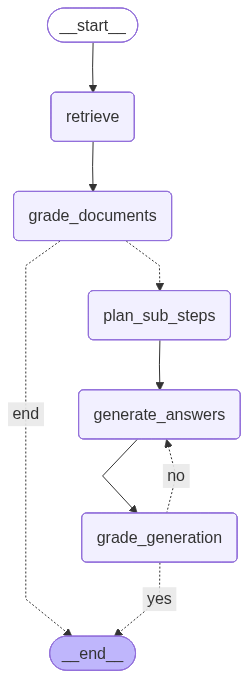

In [28]:
graph_builder.build()

In [29]:
q = "At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?"

response = graph_builder.run(q)
print(response)

---RETRIEVING DOCUMENTS FOR: At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?---
--GRADING DOCUMENTS---
---PLANNING SUB-STEPS FOR QUESTION: At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?---
---GENERATING ANSWERS FOR SUB-QUESTIONS AND FINAL ANSWER---
---GRADING GENERATION---
---GENERATION USEFUL---
{'question': 'At what age does compulsory primary education begin in Azerbaijan, and how long does the compulsory education period last?', 'temp_questions': [], 'sub_questions': {'sub_question_1': {'query': 'At what age does compulsory primary education begin in Azerbaijan?', 'id': '1', 'contexts': [Document(id='926e3901-9c3a-41c0-9dd2-25d704cf30fd', metadata={'source': '/content/drive/MyDrive/RAG/datasets/Azerbaijan.pdf', 'producer': 'Adobe PDF Library 21.1.174', 'page_label': '2', 'creationdate': '2022-10-03T15:10:45+00:00', 'moddate': '2022-1

In [31]:
response['final_answer']

'Compulsory primary education in Azerbaijan begins at age **6**. The total compulsory education period lasts **nine years**. This includes four years of primary school (Grades 1–4) and five years of lower secondary school (Grades 5–9).'

In [32]:
q = "What autonomy do schools in Italy have regarding instruction, and what condition must this autonomy satisfy?"

response = graph_builder.run(q)
print(response)

---RETRIEVING DOCUMENTS FOR: What autonomy do schools in Italy have regarding instruction, and what condition must this autonomy satisfy?---
--GRADING DOCUMENTS---
---PLANNING SUB-STEPS FOR QUESTION: What autonomy do schools in Italy have regarding instruction, and what condition must this autonomy satisfy?---
---GENERATING ANSWERS FOR SUB-QUESTIONS AND FINAL ANSWER---
---GRADING GENERATION---
---GENERATION USEFUL---
{'question': 'What autonomy do schools in Italy have regarding instruction, and what condition must this autonomy satisfy?', 'temp_questions': [], 'sub_questions': {'sub_question_1': {'query': 'What level of autonomy do schools in Italy have regarding their instructional methods?', 'id': '1', 'contexts': [Document(id='13b92727-7ecf-47d9-8ae6-95fa1706ff33', metadata={'total_pages': 11, 'sourcemodified': 'D:20220825150859', '_newreviewcycle': '', 'company': 'Boston College', 'page_label': '1', 'producer': 'Adobe PDF Library 21.1.174', 'moddate': '2022-08-25T11:11:17-04:00', 

In [34]:
q1 = "How do preschool (Cycle 1) expectations prepare French students for the Cycle 2 reading goals in decoding, fluency, and comprehension?"

response1 = graph_builder.run(q1)
print(response1['final_answer'])

---RETRIEVING DOCUMENTS FOR: How do preschool (Cycle 1) expectations prepare French students for the Cycle 2 reading goals in decoding, fluency, and comprehension?---
--GRADING DOCUMENTS---
Document graded as irrelevant: France.pdf
Document graded as irrelevant: France.pdf
Document graded as irrelevant: France.pdf
Document graded as irrelevant: France.pdf



In [ ]:
response1

In [ ]:
answers

In [ ]:
%%time

for i, q in enumerate(dataset['question'].tolist()):
    # Skip NaN values in the question list
    if isinstance(q, float) and math.isnan(q):
        print(f"Skipping question at index {i} due to NaN value.")
        continue

    print(f"Processing question {i}: {q}")
    try:
        response = graph_builder.run(q)
        answers[i] = {}
        answers[i]['query'] = get_val(response, 'question')
        answers[i]['answer'] = get_val(response, 'answer')
        answers[i]['retrieved_docs'] = []

        # Robustly check for documents in the response
        docs = get_val(response, 'documents') or get_val(response, 'retrieved_docs')

        if docs:
             for doc in docs:
                # Handle doc metadata and content safely for both dict and object types
                if isinstance(doc, dict):
                    content = doc.get('page_content', '')
                    metadata = doc.get('metadata', {})
                else:
                    content = getattr(doc, 'page_content', '')
                    metadata = getattr(doc, 'metadata', {})

                answers[i]['retrieved_docs'].append({
                    'content': content,
                    'doc_name': metadata.get('title', os.path.basename(metadata.get('source', 'unknown'))),
                    'page': metadata.get('page', 'N/A'),
                    'page_label': metadata.get('page_label', 'N/A'),
                    'source': metadata.get('source', 'unknown')
                })

    except Exception as e:
        print(f"Error processing question {i}: {e}")
        answers[i] = {'query': q, 'answer': f"Error: {str(e)}", 'retrieved_docs': []}
